# 08 — Neural Networks Intro (scikit-learn's MLP)

This is a deliberately small bridge module. scikit-learn ships a basic
feed-forward neural network — the **Multi-Layer Perceptron** (`MLPClassifier`
/ `MLPRegressor`) — which is enough to build real intuition for how neural
nets work, without needing a deep learning framework.

**This is explicitly *not* a deep learning module.** There's no GPU
acceleration, no convolutional/recurrent/transformer layers, and no
autodiff engine — for real deep learning work you'd move to PyTorch or
TensorFlow. The goal here is purely conceptual: understand what an MLP is
doing, then know where sklearn's version stops being the right tool.

**Covered:**
1. What is a neural network (perceptron -> multi-layer)
2. MLPClassifier: fitting, loss curves, decision boundaries
3. Effect of architecture (hidden layer size/depth) and activation function
4. MLPRegressor
5. Overfitting and early stopping
6. Where sklearn's MLP stops being enough

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(7)

## 1. What Is a Neural Network?

**Theory.** A single **perceptron** computes `y = activation(w·x + b)` — a
weighted sum of inputs, plus a bias, passed through a non-linear
**activation function** (e.g., ReLU, tanh, sigmoid). That's just logistic
regression with a different activation.

A **Multi-Layer Perceptron** stacks these into **layers**: an input layer,
one or more **hidden layers**, and an output layer. Each hidden layer applies
a linear transform then a non-linearity; stacking several of these lets the
network approximate far more complex, non-linear functions than any single
layer could — this is the "universal approximation" idea behind neural nets.
Training uses **backpropagation** (the chain rule, applied layer by layer)
combined with gradient descent to adjust every weight to reduce the loss.

## 2. MLPClassifier: Fitting & Loss Curves

We reuse the same non-linear "moons" shape from earlier modules so we can
directly compare the MLP's decision boundary against Logistic Regression,
KNN, Trees, and SVM from `03_classification`.

Test accuracy: 0.942
Training took 584 iterations to converge


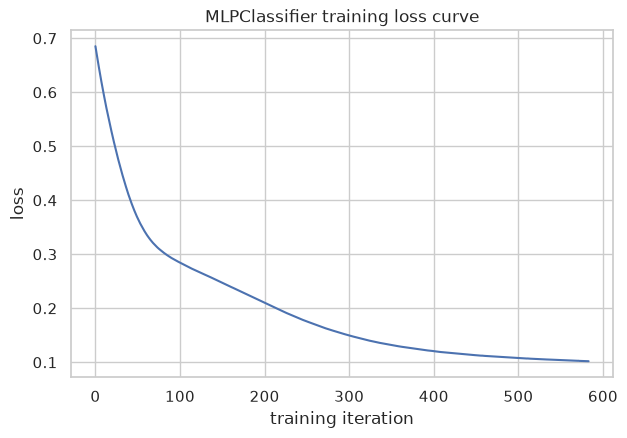

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X2, y2 = make_moons(n_samples=400, noise=0.25, random_state=7)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=7)

scaler = StandardScaler().fit(X2_train)
X2_train_s, X2_test_s = scaler.transform(X2_train), scaler.transform(X2_test)

mlp = MLPClassifier(hidden_layer_sizes=(16, 16), activation="relu", max_iter=2000, random_state=7)
mlp.fit(X2_train_s, y2_train)
print(f"Test accuracy: {mlp.score(X2_test_s, y2_test):.3f}")
print(f"Training took {mlp.n_iter_} iterations to converge")

plt.figure(figsize=(7, 4.5))
plt.plot(mlp.loss_curve_)
plt.xlabel("training iteration")
plt.ylabel("loss")
plt.title("MLPClassifier training loss curve")
plt.show()

`MLPClassifier` (like most neural nets) is trained iteratively — the loss
curve should fall smoothly and flatten out as it converges. A curve that's
still dropping sharply at `max_iter` means the model needs more iterations
(or a different learning rate) to finish converging.

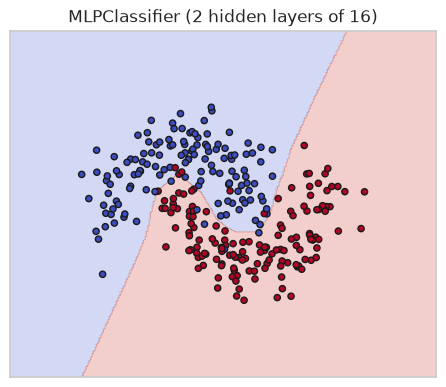

In [3]:
def plot_boundary(model, ax, title, X_fit_s, y_fit, X_full, y_full):
    x_min, x_max = X_full[:, 0].min() - 1, X_full[:, 0].max() + 1
    y_min, y_max = X_full[:, 1].min() - 1, X_full[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z = model.predict(grid_scaled).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_fit_s[:, 0] * scaler.scale_[0] + scaler.mean_[0],
               X_fit_s[:, 1] * scaler.scale_[1] + scaler.mean_[1],
               c=y_fit, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_boundary(mlp, ax, "MLPClassifier (2 hidden layers of 16)", X2_train_s, y2_train, X2, y2)
plt.show()

## 3. Effect of Architecture & Activation Function

**Hidden layer size/depth** controls model capacity — too small underfits,
too large risks overfitting (and is slower to train). **Activation function**
controls what shape of non-linearity each layer can express.

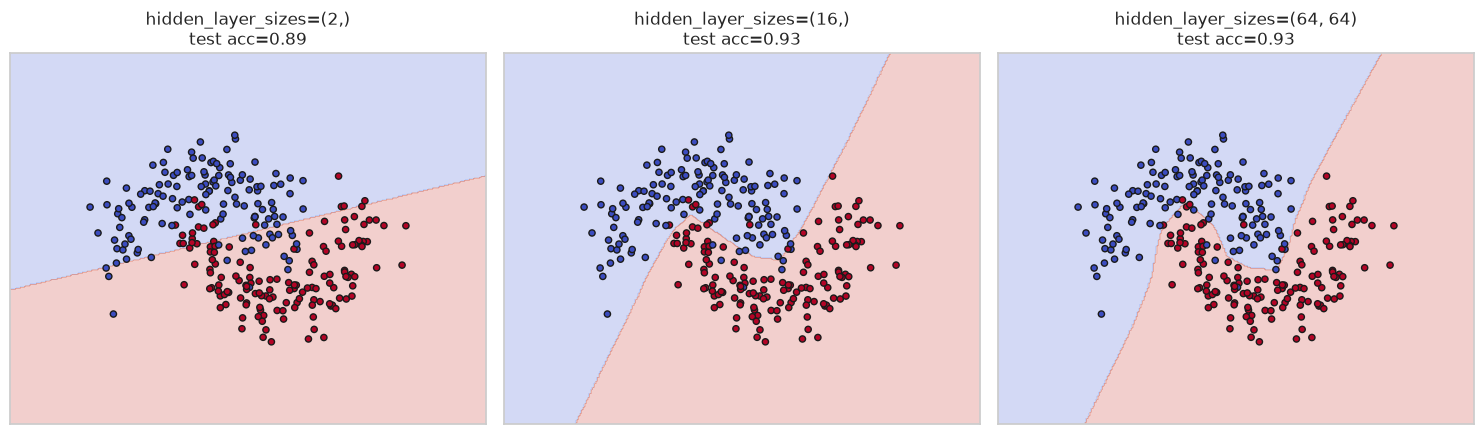

In [4]:
architectures = [(2,), (16,), (64, 64)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, hidden in zip(axes, architectures):
    m = MLPClassifier(hidden_layer_sizes=hidden, max_iter=3000, random_state=7).fit(X2_train_s, y2_train)
    acc = m.score(X2_test_s, y2_test)
    plot_boundary(m, ax, f"hidden_layer_sizes={hidden}\ntest acc={acc:.2f}", X2_train_s, y2_train, X2, y2)
plt.tight_layout()
plt.show()

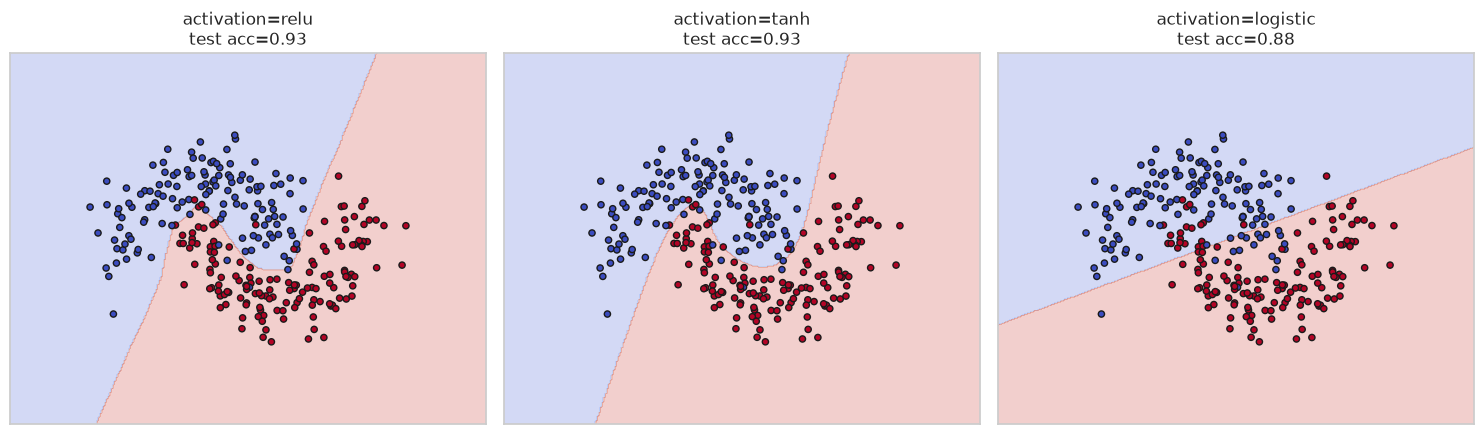

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, activation in zip(axes, ["relu", "tanh", "logistic"]):
    m = MLPClassifier(hidden_layer_sizes=(32, 32), activation=activation, max_iter=3000, random_state=7).fit(X2_train_s, y2_train)
    acc = m.score(X2_test_s, y2_test)
    plot_boundary(m, ax, f"activation={activation}\ntest acc={acc:.2f}", X2_train_s, y2_train, X2, y2)
plt.tight_layout()
plt.show()

A single tiny hidden layer, `(2,)`, barely bends beyond a straight line —
not enough capacity for this shape. `(64, 64)` fits the crescents closely.
Activation functions shape the boundary differently too: ReLU tends to
produce more piecewise-linear-looking boundaries, while tanh/logistic give
smoother curves — in practice, ReLU is the default choice for most modern
networks because it trains faster and avoids some gradient issues, but this
is worth seeing directly rather than taking on faith.

## 4. MLPRegressor

The same architecture idea, for continuous targets — comparing to
`LinearRegression` on the diabetes dataset from `02_regression` shows what a
non-linear model can (and can't, without enough data/tuning) gain over a
linear one.

In [6]:
from sklearn.datasets import load_diabetes
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=7)

d_scaler = StandardScaler().fit(Xd_train)
Xd_train_s, Xd_test_s = d_scaler.transform(Xd_train), d_scaler.transform(Xd_test)

lin = LinearRegression().fit(Xd_train, yd_train)
mlp_reg = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=5000, random_state=7, early_stopping=True)
mlp_reg.fit(Xd_train_s, yd_train)

for name, pred in [("Linear Regression", lin.predict(Xd_test)), ("MLPRegressor", mlp_reg.predict(Xd_test_s))]:
    rmse = np.sqrt(mean_squared_error(yd_test, pred))
    r2 = r2_score(yd_test, pred)
    print(f"{name:>18}: RMSE={rmse:.2f}  R2={r2:.3f}")

 Linear Regression: RMSE=54.46  R2=0.404
      MLPRegressor: RMSE=57.22  R2=0.342


On a small, mostly-linear dataset like diabetes (442 samples, 10 features),
a plain linear model is often competitive with — or better than — an MLP,
since neural nets typically need more data to earn their extra flexibility.
This is a useful reality check: bigger/fancier isn't automatically better.

## 5. Overfitting & Early Stopping

**Theory.** Like any high-capacity model, a large MLP can overfit given
enough training iterations. `early_stopping=True` holds out part of the
training data as a validation set internally and stops training once
validation score stops improving — a direct, practical defense against
overfitting, without needing a separate learning-curve analysis every time.

No early stopping:   ran 368 iterations, test acc=0.925
With early stopping: ran 26 iterations, test acc=0.875


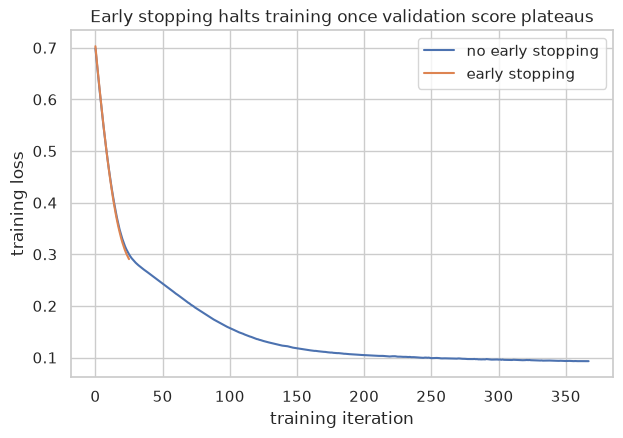

In [7]:
mlp_no_stop = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=7, early_stopping=False)
mlp_no_stop.fit(X2_train_s, y2_train)

mlp_early_stop = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=7,
                                early_stopping=True, n_iter_no_change=15, validation_fraction=0.15)
mlp_early_stop.fit(X2_train_s, y2_train)

print(f"No early stopping:   ran {mlp_no_stop.n_iter_} iterations, test acc={mlp_no_stop.score(X2_test_s, y2_test):.3f}")
print(f"With early stopping: ran {mlp_early_stop.n_iter_} iterations, test acc={mlp_early_stop.score(X2_test_s, y2_test):.3f}")

plt.figure(figsize=(7, 4.5))
plt.plot(mlp_no_stop.loss_curve_, label="no early stopping")
plt.plot(mlp_early_stop.loss_curve_, label="early stopping")
plt.xlabel("training iteration")
plt.ylabel("training loss")
plt.title("Early stopping halts training once validation score plateaus")
plt.legend()
plt.show()

## 6. Where sklearn's MLP Stops Being Enough

sklearn's MLP is genuinely useful for small-to-medium tabular problems, but
it's missing everything that makes modern deep learning "deep learning":

| | sklearn MLP | PyTorch / TensorFlow |
|---|---|---|
| Layer types | Dense (fully-connected) only | Convolutional, recurrent, attention/transformer, etc. |
| Hardware | CPU only | GPU/TPU acceleration |
| Data | Fits in memory, tabular-shaped | Streaming/batched pipelines for images, text, audio, video |
| Custom architectures | Fixed set of options | Fully programmable computation graphs |
| Scale | Small-to-medium datasets | Millions to billions of parameters/samples |

For images, text, audio, or very large datasets, a dedicated deep learning
framework is the right next step — but for structured/tabular data (which is
most of this syllabus), tree ensembles from `02_regression`/`04_ensemble_methods`
are frequently *more* accurate than a small MLP, and much easier to tune.

## Exercises

1. Try `hidden_layer_sizes=(4,)` on the moons data — how much worse is the decision boundary than `(16,)`?
2. Change `activation="relu"` to `activation="identity"` (no non-linearity at all) in the architecture comparison — what happens to the boundary shape, and why does that make sense given section 1's theory?
3. Re-run the MLPRegressor comparison with `hidden_layer_sizes=(128, 64, 32)` — does a bigger network help on this small dataset, or start to overfit?

## Key Takeaways

- An MLP is layers of perceptrons (linear transform + non-linear activation), trained via backpropagation + gradient descent.
- Architecture (layer sizes/depth) and activation function both shape what the network can represent — bigger isn't always better, especially on small datasets.
- `early_stopping=True` is a simple, effective overfitting guard for neural nets, mirroring the learning-curve diagnosis from `06_model_selection_tuning`.
- sklearn's MLP is a solid learning tool and occasionally useful in production for small tabular problems, but real deep learning (images, text, large scale) needs PyTorch/TensorFlow — out of scope for this syllabus.